In [1]:
# import libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.api import VARMAX

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [42]:
# read in data
df = pd.read_csv('../datasets/TX-Data/met-cleanedup/met_data1_cleaned.csv', sep=",", parse_dates=["Date"], index_col="Date")

In [43]:
# Slice data to isolate 2015-2020
df = df[(df.index > "2014-12-31 23:00") & (df.index < "2020-12-31 23:00")]

In [44]:
# Replace inf values and Fill nan values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(), inplace=True)

In [45]:
# Reseample with monthly mean
df = df.resample('M').mean()

In [46]:
# removes spaces in the column names
def remove_spaces(df):
    df.columns = df.columns.str.replace(' ','')
    df['Ppt'] = df['Ppt'].astype(float)
    df['Tair'] = df['Tair'].astype(float)
    df['RH'] = df['RH'].astype(float)
    df['Windspeed'] = df['Windspeed'].astype(float)
    df['Winddirection'] = df['Winddirection'].astype(float)
    df['Srad'] = df['Srad'].astype(float)  

In [47]:
# remove column name spaces of each DataFrame 
remove_spaces(df)

In [48]:
drop_exog_cols = ['Ppt', 'RH', 'Windspeed', 'Winddirection']
endog = df.drop(drop_cols, axis=1)


drop_endog_cols = ['Tair', 'Srad']
exog = df.drop(drop_cols, axis=1)

In [49]:
# Verify shape of data frame
df.shape

(72, 6)

In [66]:
train_len = 60
order = (3, 3)
VARMAX_model = VARMAX(endog[:train_len], order = order)
results = VARMAX_model.fit()

In [67]:
results.summary()

Dep. Variable:,"['Tair', 'Srad']",No. Observations:,60
Model:,"VARMA(3,3)",Log Likelihood,-370.915
,+ intercept,AIC,799.830
Date:,"Mon, 14 Aug 2023",BIC,860.566
Time:,14:29:56,HQIC,823.588
Sample:,01-31-2015,,
,- 12-31-2019,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.11, 0.11",Jarque-Bera (JB):,"0.88, 1.30"
Prob(Q):,"0.74, 0.74",Prob(JB):,"0.64, 0.52"
Heteroskedasticity (H):,"0.93, 0.93",Skew:,"-0.26, -0.34"


In [68]:
# Forecast 12 months
forecast_steps = 12

forecast = results.forecast(steps=forecast_steps)

forecast
# Convert the forecast array to a DataFrame
forecast_df = pd.DataFrame(forecast, columns=['Tair', 'Srad'])

# Display the forecasted values
print("\nForecasted Values:")
print(forecast_df)


Forecasted Values:
                 Tair        Srad
2020-01-31  10.365476  123.952124
2020-02-29  12.171958  154.579622
2020-03-31  15.201945  190.194664
2020-04-30  19.666337  228.913117
2020-05-31  23.437959  255.489282
2020-06-30  26.132398  271.647605
2020-07-31  26.758106  264.305631
2020-08-31  25.603263  243.389856
2020-09-30  22.661636  210.209127
2020-10-31  19.074632  177.535002
2020-11-30  15.550269  149.925497
2020-12-31  13.174461  137.633841


In [69]:
total_len = len(df.Tair)
forecast_x_values = range(total_len - len(forecast_df.Tair), total_len)

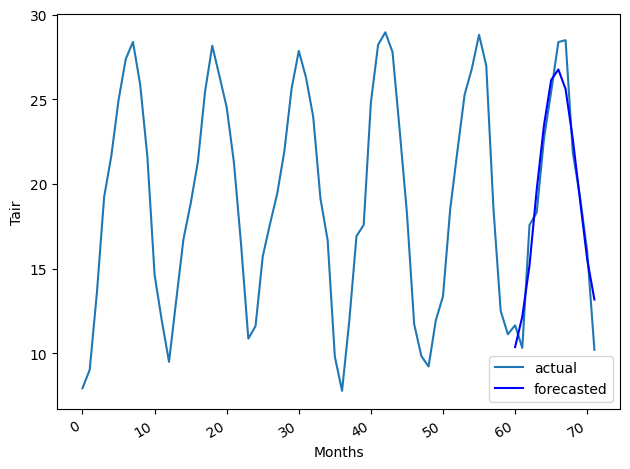

In [70]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Tair.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Tair, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Tair')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

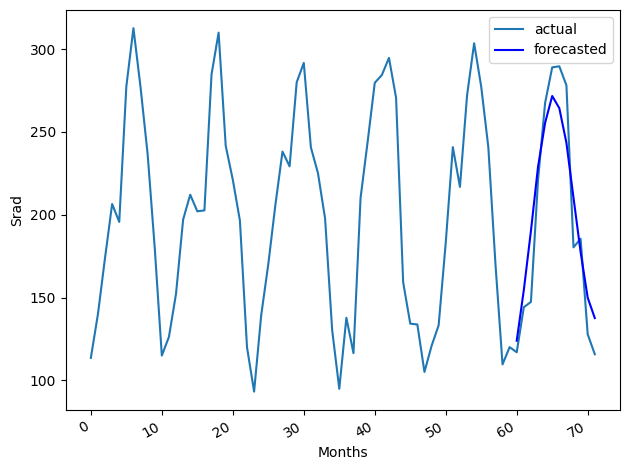

In [71]:
# Visualize predictions
fig, ax = plt.subplots()

# Plot actual data
ax.plot(df.Srad.tolist(), label='actual')

# Plot forecasted data with adjusted x-axis values
ax.plot(forecast_x_values, forecast_df.Srad, 'b-', label='forecasted')

ax.set_xlabel('Months')
ax.set_ylabel('Srad')
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

# Show the plot
plt.show()

In [72]:
mse_srad = mean_squared_error(forecast_df.Srad,df.Srad.tolist()[60:])
mse_srad

521.7042355899969

In [73]:
mse_tair = mean_squared_error(forecast_df.Tair,df.Tair.tolist()[60:])
mse_tair

2.852423470235839